# One Tune, Many Stories
## Tune Reuse and Topic Diversity in Early Modern English Ballads

This study compares the topic distributions of six standardized EBBA tune categories and examines whether lyrics associated with the same tune share more vocabulary. The analysis presents corpus selection, topic diversity, the tune–topic network, lexical similarity, and sensitivity to closely related versions.

This notebook contains the main workflow and algorithm definitions. Run its cells sequentially from the repository root. The default settings use the included archive snapshot. Set `OFFLINE=False` to download missing data and `REFRESH=True` to retrieve the records in the fixed manifest again. Changes to the source data require a fresh interpretation of the results. Dependencies appear in `requirements.txt`. Execution generates all statistics and figures; the saved outputs come from an actual run.

In [1]:
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime, timezone
from urllib.robotparser import RobotFileParser
import copy, hashlib, json, os, platform, re, time, unicodedata
import urllib.request, urllib.error
import numpy as np
import pandas as pd
import sklearn
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from lxml import etree, html
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display, Image, Markdown

candidates = [Path.cwd(), *Path.cwd().parents, Path.cwd() / 'ballad_reuse']
ROOT = next((p for p in candidates if (p / 'configs/default.json').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Run this notebook from the extracted ballad_reuse repository.')
config = json.loads((ROOT / 'configs/default.json').read_text())
# Defaults use the included snapshot; run.py can override them through the environment.
OFFLINE = os.environ.get('BALLAD_OFFLINE', '1') == '1'
REFRESH = os.environ.get('BALLAD_REFRESH', '0') == '1' 
if OFFLINE and REFRESH:
    raise ValueError('OFFLINE and REFRESH cannot both be enabled.')
for name in ['data/processed', 'results/figures']:
    (ROOT / name).mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13,
                    'axes.spines.top': False, 'axes.spines.right': False, 'savefig.dpi': 170})
BASE = 'https://ebba.english.ucsb.edu'
AGENT = 'BalladReuseEducationalProject/1.0'
COLORS = ['#326f8e', '#d0923c', '#528571', '#98637a', '#7975a5', '#b85e4b']
SHORT_NAMES = {'32': 'Greensleeves', '42': 'Fortune my Foe', '67': 'Chevy Chase',
               '35': "Packington's Pound", '18': 'Come Live with Me', '168': 'Children in the Wood'}
def save(name):
    dest = ROOT / 'results/figures'
    plt.savefig(dest / f'{name}.png', bbox_inches='tight', facecolor='white')
    plt.savefig(dest / f'{name}.pdf', bbox_inches='tight', facecolor='white')
    plt.close()
    display(Image(filename=str(dest / f'{name}.png')))

## Data sources and content validation
The sample contains records from the first two result pages for each preselected tune, with a maximum of twenty records per tune. A fixed manifest preserves the sample. Validation checks the TEI structure, EBBA identifiers, and content hashes. The downloader retains HTTP access logs. Default offline execution uses earlier downloads and does not represent a new online availability check. Four known unavailable sources return the literal body `Error`; unexpected failures stop the analysis.

Topic labels come from the EMCKEYWORDS assigned to each ballad. The text model uses verse lines only. Joining inline markup preserves letters within words.

In [2]:
def write_json(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding='utf-8')

def sha256(data):
    return hashlib.sha256(data).hexdigest()

def xml_root(data):
    # Never retrieve the historical external TEI DTD or expand external entities.
    parser = etree.XMLParser(resolve_entities=False, load_dtd=False, no_network=True)
    root = etree.fromstring(data, parser)
    if etree.QName(root).localname not in {'TEI.2', 'TEI'}:
        raise ValueError('Response is not TEI XML')
    if list(root.iter(etree.Entity)):
        raise ValueError('Unresolved XML entity: inspect source, do not silently lose text')
    for el in root.iter():
        if isinstance(el.tag, str):
            el.tag = etree.QName(el).localname
    return root

def text(el):
    # Join inline markup without inserting spaces into words: <hi>L</hi>ove.
    return '' if el is None else re.sub(r'\s+', ' ', ''.join(el.itertext())).strip()

def key(s):
    return re.sub(r'[^a-z0-9]', '', unicodedata.normalize('NFKC', s).lower())

def normalize_lyrics(s):
    # Keep historical spelling; remove editorial brackets, not supplied letters.
    s = unicodedata.normalize('NFKC', s).lower().replace('’', "'")
    s = s.replace('[', '').replace(']', '')
    return ' '.join(re.findall(r"[a-z]+(?:'[a-z]+)?", s))

def extract_record(data, expected_id):
    r = xml_root(data)
    rid = text(r.find("./teiHeader/fileDesc/publicationStmt/idno[@type='EMC']"))
    if rid != str(expected_id):
        raise ValueError(f'Expected EBBA {expected_id}, got {rid!r}')
    title = text(r.find('./teiHeader/fileDesc/titleStmt/title'))
    if not title:
        raise ValueError(f'EBBA {rid}: missing title')
    taxonomy = {}
    for cat in r.findall(".//taxonomy[@id='EMCKEYWORDS']/category"):
        label = text(cat.find('catDesc'))
        taxonomy[key(label)] = label
    raw_keywords = [text(x) for x in r.findall(".//profileDesc/textClass/keywords[@scheme='EMCKEYWORDS']//item") if text(x)]
    keywords = sorted({taxonomy.get(key(s), s) for s in raw_keywords})
    unmatched = sorted({s for s in raw_keywords if key(s) not in taxonomy})
    notes = {x.get('type', ''): text(x) for x in r.findall('./teiHeader/fileDesc/notesStmt/note')}
    source = r.find('./teiHeader/fileDesc/sourceDesc')
    date_el = None if source is None else source.find('.//bibl/imprint/date')
    lyrics_lines = [text(x) for x in r.findall('.//text/body//l') if text(x)]
    lyrics = '\n'.join(lyrics_lines)
    return {
        'ebba_id': rid, 'title': title,
        'date_text': text(date_el),
        'date_attributes': dict(date_el.attrib) if date_el is not None else {},
        'holding_library': text(r.find('.//sourceDesc//monogr/author')),
        'source_reference': notes.get('Source', ''),
        'source_bibliographic_title': text(r.find('.//sourceDesc//monogr/title')),
        'source_volume_page': text(r.find('.//sourceDesc//biblScope')),
        'shelfmarks': {x.get('type'): text(x) for x in r.findall('./teiHeader/fileDesc/publicationStmt/idno') if x.get('type') not in {'EMC', 'ESTC'}},
        'keywords_raw': raw_keywords, 'keywords': keywords,
        'unmatched_keywords': unmatched,
        'tune_notes': {k: v for k, v in notes.items() if k.startswith('Tune')},
        'lyrics': lyrics, 'normalized_lyrics': normalize_lyrics(lyrics),
        'line_count': len(lyrics_lines),
        'source_url': f'{BASE}/ballad/{rid}/citation',
        'xml_url': f'{BASE}/ballad/{rid}/ebba-xml-{rid}',
        'sha256': sha256(data)
    }

In [3]:
class Downloader:
    def __init__(self, root, delay=0.8, offline=False, refresh=False):
        self.root = Path(root)
        self.raw = self.root / 'data/raw'
        self.raw.mkdir(parents=True, exist_ok=True)
        self.delay, self.offline, self.refresh = delay, offline, refresh
        self.log_path = self.raw / 'download_log.jsonl'
        self.robot = None

    def get(self, url, path, kind):
        path = Path(path)
        if path.exists() and not self.refresh:
            data = path.read_bytes()
            if kind == 'xml':
                xml_root(data)
            return data
        if self.offline:
            raise FileNotFoundError(f'Offline snapshot missing: {path}')
        if self.robot is not None and not self.robot.can_fetch(AGENT, url):
            raise PermissionError(f'robots.txt disallows {url}')
        error = None
        for attempt in range(1, 4):
            time.sleep(self.delay)
            event = {'url': url, 'file': str(path.relative_to(self.root)),
                     'accessed_utc': datetime.now(timezone.utc).isoformat(), 'attempt': attempt}
            try:
                req = urllib.request.Request(url, headers={'User-Agent': AGENT})
                with urllib.request.urlopen(req, timeout=35) as response:
                    body = response.read(5_000_001)
                    if len(body) > 5_000_000:
                        raise ValueError('Unexpected response larger than 5 MB')
                    event.update(status=response.status, final_url=response.geturl(),
                                 content_type=response.headers.get('Content-Type'), bytes=len(body), sha256=sha256(body))
                if kind == 'xml':
                    xml_root(body)
                elif kind == 'search':
                    if b'Search Results' not in body:
                        raise ValueError('Search results marker missing')
                path.parent.mkdir(parents=True, exist_ok=True)
                temp = path.with_suffix(path.suffix + '.part')
                temp.write_bytes(body)
                temp.replace(path)
                event['ok'] = True
                self._log(event)
                return body
            except Exception as exc:
                error = exc
                event.update(ok=False, error=f'{type(exc).__name__}: {exc}')
                self._log(event)
                if isinstance(exc, urllib.error.HTTPError) and exc.code in (401, 403, 404):
                    break
        raise RuntimeError(f'Download failed: {url}: {error}')

    def _log(self, event):
        with self.log_path.open('a', encoding='utf-8') as f:
            f.write(json.dumps(event, ensure_ascii=False) + '\n')

    def run(self, config):
        if not self.offline:
            robots = self.get(BASE + '/robots.txt', self.raw / 'robots.txt', 'text')
            self.robot = RobotFileParser()
            self.robot.parse(robots.decode('utf-8').splitlines())
        manifest_path = self.root / 'data/manifest.json'
        # Freeze IDs once discovered, so later runs do not drift with website ordering.
        if manifest_path.exists():
            manifest = json.loads(manifest_path.read_text())
            if manifest['tunes'] != config['tunes'] or manifest['pages_per_tune'] != config['pages_per_tune'] or manifest['records_per_tune'] != config['records_per_tune']:
                raise ValueError('Sampling config differs from frozen manifest; use a new project copy')
        else:
            memberships, searches = {}, []
            for tune, name in config['tunes'].items():
                found = []
                for page in range(1, config['pages_per_tune'] + 1):
                    url = f'{BASE}/search_combined/?tst={tune}&p={page}'
                    raw = self.get(url, self.raw / f'search_{tune}_{page}.html', 'search')
                    dom = html.fromstring(raw)
                    ids = []
                    for href in dom.xpath('//a/@href'):
                        m = re.fullmatch(r'/ballad/(\d+)/citation', href)
                        if m and m[1] not in ids:
                            ids.append(m[1])
                    if not ids:
                        break
                    found.extend(x for x in ids if x not in found)
                    searches.append({'tune_id': tune, 'page': page, 'url': url, 'ids': ids, 'sha256': sha256(raw)})
                for rid in found[:config['records_per_tune']]:
                    memberships.setdefault(rid, []).append(tune)
                print(f'Discovered {name}: {len(found[:config["records_per_tune"]])} records', flush=True)
            if not memberships:
                raise ValueError('No ballads discovered')
            manifest = {'tunes': config['tunes'], 'pages_per_tune': config['pages_per_tune'],
                        'records_per_tune': config['records_per_tune'], 'searches': searches,
                        'memberships': memberships,
                        'sampling': 'First two search-result pages per preselected tune, at most 20 records; convenience sample, not random.'}
            write_json(manifest_path, manifest)
        failures = []
        unavailable = config.get('unavailable_ids', [])
        for rid in unavailable:
            body = self.get(f'{BASE}/ballad/{rid}/ebba-xml-{rid}', self.raw / f'{rid}.error.txt', 'text')
            if body != b'Error':
                raise ValueError(f'Previously unavailable {rid} changed; review source eligibility in a new snapshot')
        write_json(self.root / 'results/unavailable_sources.json', [
            {'ebba_id': rid, 'reason': 'HTTP 200 body is literal Error, not TEI XML',
             'url': f'{BASE}/ballad/{rid}/ebba-xml-{rid}',
             'sha256': sha256((self.raw / f'{rid}.error.txt').read_bytes())}
            for rid in unavailable])
        def fetch_one(rid):
            if rid in unavailable:
                return None
            try:
                data = self.get(f'{BASE}/ballad/{rid}/ebba-xml-{rid}', self.raw / f'{rid}.xml', 'xml')
                extract_record(data, rid)
                return None
            except Exception as exc:
                return {'ebba_id': rid, 'error': str(exc)}
        with ThreadPoolExecutor(max_workers=2) as pool:
            for i, failure in enumerate(pool.map(fetch_one, sorted(manifest['memberships']))):
                if failure:
                    failures.append(failure)
                if (i + 1) % 10 == 0:
                    print(f'XML checked: {i+1}/{len(manifest["memberships"])}', flush=True)
        if failures:
            write_json(self.root / 'results/download_failures.json', failures)
        else:
            (self.root / 'results/download_failures.json').unlink(missing_ok=True)
        if failures:
            raise RuntimeError(f'{len(failures)} records failed; see results/download_failures.json. No silent sample reduction.')
        checksum_path = self.root / 'data/source_checksums.json'
        files = [f'{rid}.error.txt' if rid in unavailable else f'{rid}.xml' for rid in manifest['memberships']]
        checksums = {name: sha256((self.raw / name).read_bytes()) for name in files}
        if checksum_path.exists() and not self.refresh:
            expected = json.loads(checksum_path.read_text())
            if expected != checksums:
                raise ValueError('Source snapshot checksum mismatch; restore original files or explicitly --refresh')
        else:
            write_json(checksum_path, checksums)
        return manifest

In [4]:
manifest = Downloader(ROOT, config['delay_seconds'], offline=OFFLINE, refresh=REFRESH).run(config)
source_checks = []
for rid in sorted(manifest['memberships']):
    unavailable = rid in config['unavailable_ids']
    path = ROOT / 'data/raw' / (f'{rid}.error.txt' if unavailable else f'{rid}.xml')
    source_checks.append({'ebba_id': rid, 'bytes': path.stat().st_size,
                         'status': 'Error response' if unavailable else 'Valid TEI XML'})
source_checks = pd.DataFrame(source_checks)
display(source_checks.groupby('status').agg(records=('ebba_id', 'size'), bytes=('bytes', 'sum')))

XML checked: 10/101
XML checked: 20/101
XML checked: 30/101
XML checked: 40/101
XML checked: 50/101
XML checked: 60/101
XML checked: 70/101
XML checked: 80/101
XML checked: 90/101
XML checked: 100/101


,records,bytes
status,,
Error response,4,20
Valid TEI XML,97,3315954


## Corpus preparation and lyric normalization
Normalization converts lyrics to lowercase while retaining historical spelling and supplied letters inside square brackets. Records without the required topic labels or with fewer than fifty tokens do not enter the joint analysis. Records with identical normalized lyrics collapse into one representative. The lowest-ID record supplies the topic labels, and the group retains all observed selected-tune memberships.

In [5]:
def save_csv(path, rows, columns=None):
    pd.DataFrame(rows, columns=columns).to_csv(path, index=False, encoding='utf-8-sig')

def build_corpus(root, manifest):
    records, excluded = [], []
    unavailable = json.loads((root / 'configs/default.json').read_text()).get('unavailable_ids', [])
    labels = {}
    aliases = json.loads((root / "configs/topic_aliases.json").read_text())
    for rid in sorted(manifest['memberships']):
        if rid in unavailable:
            continue
        record = extract_record((root / f'data/raw/{rid}.xml').read_bytes(), rid)
        record['tunes'] = sorted(manifest['memberships'][rid])
        record['tokens'] = len(record['normalized_lyrics'].split())
        record['topic_keys'] = sorted({aliases.get(key(s), {}).get('key', key(s)) for s in record['keywords']})
        for k, s in zip([key(s) for s in record['keywords']], record['keywords']):
            # Same key merges whitespace/case/punctuation only, not semantic synonyms.
            labels.setdefault(aliases.get(k, {}).get('key', k), aliases.get(k, {}).get('label', s))
        reasons = []
        if record['tokens'] < 50:
            reasons.append('fewer_than_50_lyric_tokens')
        if not record['topic_keys']:
            reasons.append('no_archive_keywords')
        record['exclusion_reasons'] = reasons
        if reasons:
            excluded.append(record)
        else:
            records.append(record)
    write_json(root/'data/processed/excluded_records.json', excluded)
    write_json(root/'data/processed/topic_labels.json', labels)
    return records, excluded, labels

def deduplicate(records):
    """Collapse exactly equal normalized lyrics, preserving all proven tune links."""
    groups = {}
    for r in records:
        fingerprint = hashlib.sha256(r['normalized_lyrics'].encode()).hexdigest()
        if fingerprint not in groups:
            representative = copy.deepcopy(r)
            representative['member_ids'] = [r['ebba_id']]
            groups[fingerprint] = representative
        else:
            representative = groups[fingerprint]
            representative['member_ids'].append(r['ebba_id'])
            representative['tunes'] = sorted(set(representative['tunes']) | set(r['tunes']))
            # Keep the representative's keyword set, preventing edition-driven inflation.
    return list(groups.values())

,stage,records
0,Candidate IDs,101
1,Valid XML,97
2,Eligible records,65
3,Distinct lyrics,64


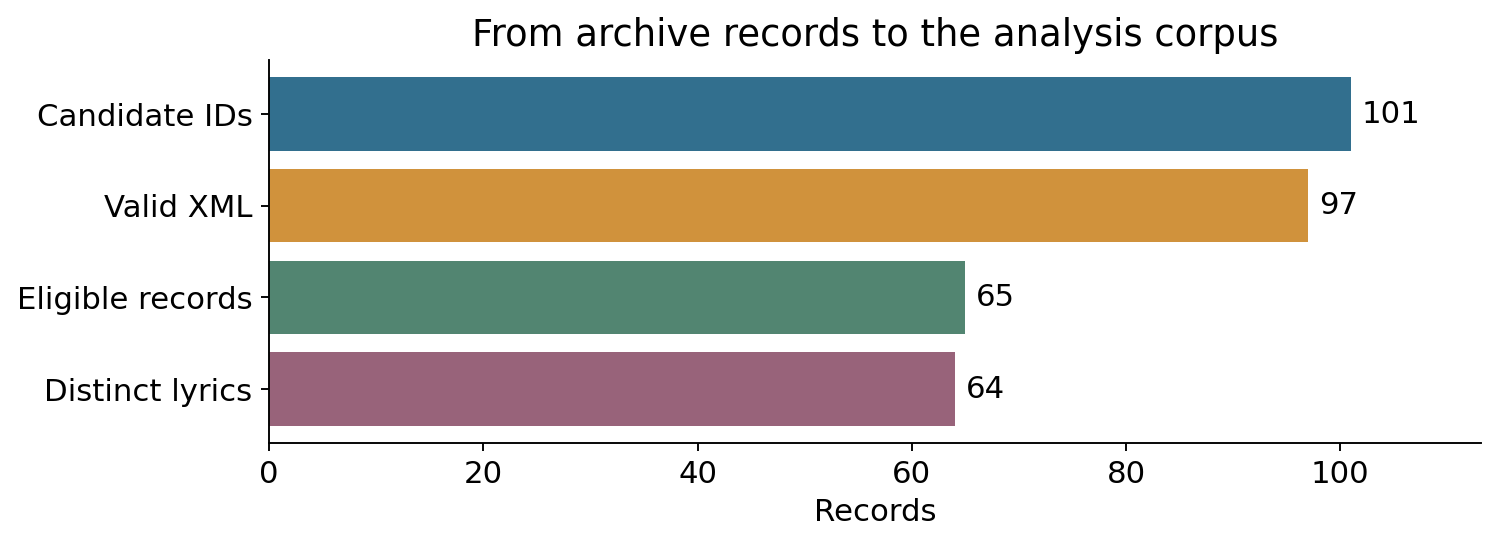

,ebba_id,title,tokens,topics
0,20229,"The woful Lamentation of Mistris Jane Shore, a...",1994,"historical figures & events, infidelity, marri..."
1,20235,"A Lamentable Ballad of Fair Rosamond, King Hen...",1084,"gender, infidelity, maritime, punishment, roya..."
2,20251,A most Excellent Ballad of St. George for Engl...,1726,"love, marriage, religious figures, violence, v..."
3,20265,"A most sorrowfull Song, setting forth the mise...",1041,"class, infidelity, nobility/court, politics/go..."
4,20278,"A new Ballad, intituled, The Battell of Agen-C...",623,"country/nation, death, historical figures & ev..."
5,20279,A memorable song vpon the vnhappy hunting in C...,1493,"country/nation, military/war, nobility/court, ..."


In [6]:
records, excluded, labels = build_corpus(ROOT, manifest)
unique = deduplicate(records)
write_json(ROOT / 'data/processed/analysis_records.json', unique)
save_csv(ROOT / 'data/processed/catalog.csv', [
    {k: json.dumps(v, ensure_ascii=False) if isinstance(v, (list, dict)) else v
     for k, v in r.items() if k not in {'lyrics', 'normalized_lyrics'}} for r in records + excluded])
save_csv(ROOT / 'results/duplicate_groups.csv', [
    {'representative': r['ebba_id'], 'member_ids': '|'.join(r['member_ids'])}
    for r in unique if len(r['member_ids']) > 1], ['representative', 'member_ids'])
flow = pd.DataFrame({'stage': ['Candidate IDs', 'Valid XML', 'Eligible records', 'Distinct lyrics'],
                     'records': [len(manifest['memberships']), len(records) + len(excluded), len(records), len(unique)]})
display(flow)
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh(flow['stage'], flow['records'], color=COLORS[:4]); ax.invert_yaxis()
for i, n in enumerate(flow['records']): ax.text(n + 1, i, str(n), va='center')
ax.set_xlim(0, flow['records'].max() * 1.12); ax.set_xlabel('Records')
ax.set_title('From archive records to the analysis corpus'); fig.tight_layout(); save('sample_flow')
display(pd.DataFrame([{'ebba_id': r['ebba_id'], 'title': r['title'], 'tokens': r['tokens'],
                       'topics': ', '.join(r['keywords'])} for r in unique]).head(6))

## Tunes and topic diversity
Each record contributes a total weight of one within each associated tune, divided equally among its assigned topics. If a tune's topic shares are $p_k$, its effective topic diversity is $\exp(-\sum_k p_k\log p_k)$. This measure reflects both the number of topics and the evenness of their distribution.

Five hundred within-tune bootstrap resamples describe variation in the observed sample. These ranges do not correct for convenience-sampling bias.

In [7]:
def topic_matrix(records, tune_ids, topic_ids):
    weights = np.zeros((len(tune_ids), len(topic_ids)))
    counts = np.zeros(len(tune_ids), dtype=int)
    ti, ki = {t:i for i,t in enumerate(tune_ids)}, {k:i for i,k in enumerate(topic_ids)}
    for r in records:
        for t in r['tunes']:
            if t not in ti:
                continue
            counts[ti[t]] += 1
            for k in r['topic_keys']:
                weights[ti[t], ki[k]] += 1 / len(r['topic_keys'])
    return weights, counts

def entropy(v):
    v = np.asarray(v, dtype=float)
    if v.sum() == 0:
        return float('nan')
    p = v[v > 0] / v.sum()
    return float(-(p * np.log(p)).sum())

def describe_tunes(records, tune_ids, topic_ids, config):
    weights, counts = topic_matrix(records, tune_ids, topic_ids)
    rng = np.random.default_rng(config['seed'])
    rows = []
    for i,t in enumerate(tune_ids):
        subset = [r for r in records if t in r['tunes']]
        h = entropy(weights[i])
        boot = []
        if subset:
            for _ in range(config['bootstrap_repeats']):
                sample = [subset[j] for j in rng.integers(len(subset), size=len(subset))]
                w,_ = topic_matrix(sample, [t], topic_ids)
                boot.append(np.exp(entropy(w[0])))
        lo,hi = np.quantile(boot, [.025,.975]) if boot else (np.nan,np.nan)
        rows.append({'tune_id':t, 'tune':config['tunes'][t], 'n_records':int(counts[i]),
                     'n_topics':int((weights[i]>0).sum()), 'entropy_nats':h,
                     'effective_topics':float(np.exp(h)), 'bootstrap_low':float(lo), 'bootstrap_high':float(hi)})
    return rows, weights

In [8]:
tune_ids = list(config['tunes'])
topic_ids = sorted({k for r in records for k in r['topic_keys']})
rows, weights = describe_tunes(unique, tune_ids, topic_ids, config)
assert np.allclose(weights.sum(axis=1), [r['n_records'] for r in rows])
save_csv(ROOT / 'results/tune_metrics.csv', rows)
edges = [{'tune_id': t, 'tune': config['tunes'][t], 'topic_key': topic_ids[k],
          'topic': labels[topic_ids[k]], 'weight': float(weights[i,k])}
         for i, t in enumerate(tune_ids) for k in range(len(topic_ids)) if weights[i,k] > 0]
save_csv(ROOT / 'results/network_edges.csv', edges)
display(pd.DataFrame(rows)[['tune', 'n_records', 'n_topics', 'effective_topics', 'bootstrap_low', 'bootstrap_high']].round(4))

,tune,n_records,n_topics,effective_topics,bootstrap_low,bootstrap_high
0,Greensleeves,12,21,16.0563,8.5014,16.6429
1,Fortune my Foe,14,17,10.7080,6.2910,12.1496
2,Chevy Chase,14,23,18.1752,11.9098,19.4344
3,Packington's Pound,8,9,5.0324,2.8946,6.4906
4,Come Live with Me and Be My Love,14,25,19.5273,12.9526,21.6307
5,"Children in the Wood, The; Now Ponder Well",2,11,10.1863,5.0000,10.1863


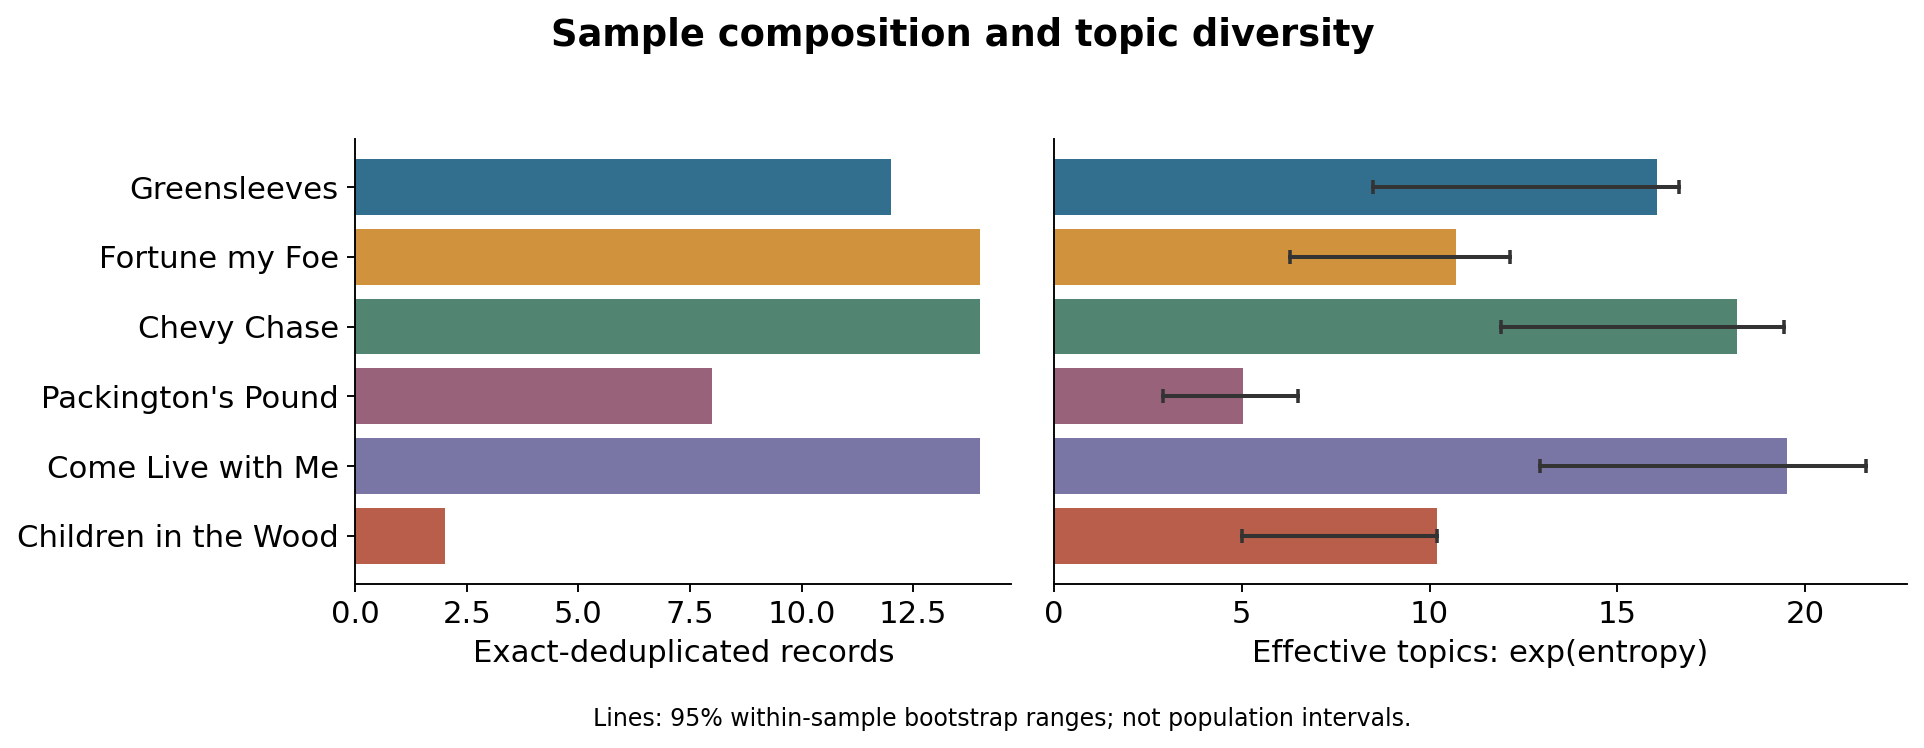

In [9]:
# Sample size and effective topic diversity are shown together.
fig,axs=plt.subplots(1,2,figsize=(11.5,4.3),gridspec_kw={'width_ratios':[1,1.3]})
names=[SHORT_NAMES[t] for t in tune_ids]
n=np.array([r['n_records'] for r in rows])
eff=np.array([r['effective_topics'] for r in rows])
axs[0].barh(names,n,color=COLORS);axs[0].invert_yaxis();axs[0].set_xlabel('Exact-deduplicated records')
axs[1].barh(names,eff,color=COLORS)
# Percentile resampling ranges may not contain the original estimator.
for i,r in enumerate(rows):
    axs[1].plot([r['bootstrap_low'],r['bootstrap_high']],[i,i],color='#333333',lw=1.7)
    axs[1].scatter([r['bootstrap_low'],r['bootstrap_high']],[i,i],marker='|',color='#333333')
axs[1].invert_yaxis();axs[1].set_xlabel('Effective topics: exp(entropy)')
axs[1].set_yticks([])
fig.suptitle('Sample composition and topic diversity',fontweight='bold')
fig.text(.52,.01,'Lines: 95% within-sample bootstrap ranges; not population intervals.',fontsize=10,ha='center')
fig.tight_layout(rect=[0,.04,1,.95]);save('diversity')

### Equal-size comparison
The analysis determines a common sample size among tunes with at least five records. Each of five hundred repetitions draws eight records per eligible tune without replacement. Children in the Wood has only two records and does not enter this comparison.

,tune,sample_size,mean_effective_topics,q025,q975
0,Greensleeves,8,13.3853,9.3172,17.5586
1,Fortune my Foe,8,9.4020,6.6739,12.7080
2,Chevy Chase,8,15.9876,11.8645,19.8826
3,Packington's Pound,8,5.0324,5.0324,5.0324
4,Come Live with Me,8,17.5936,13.4302,21.1102


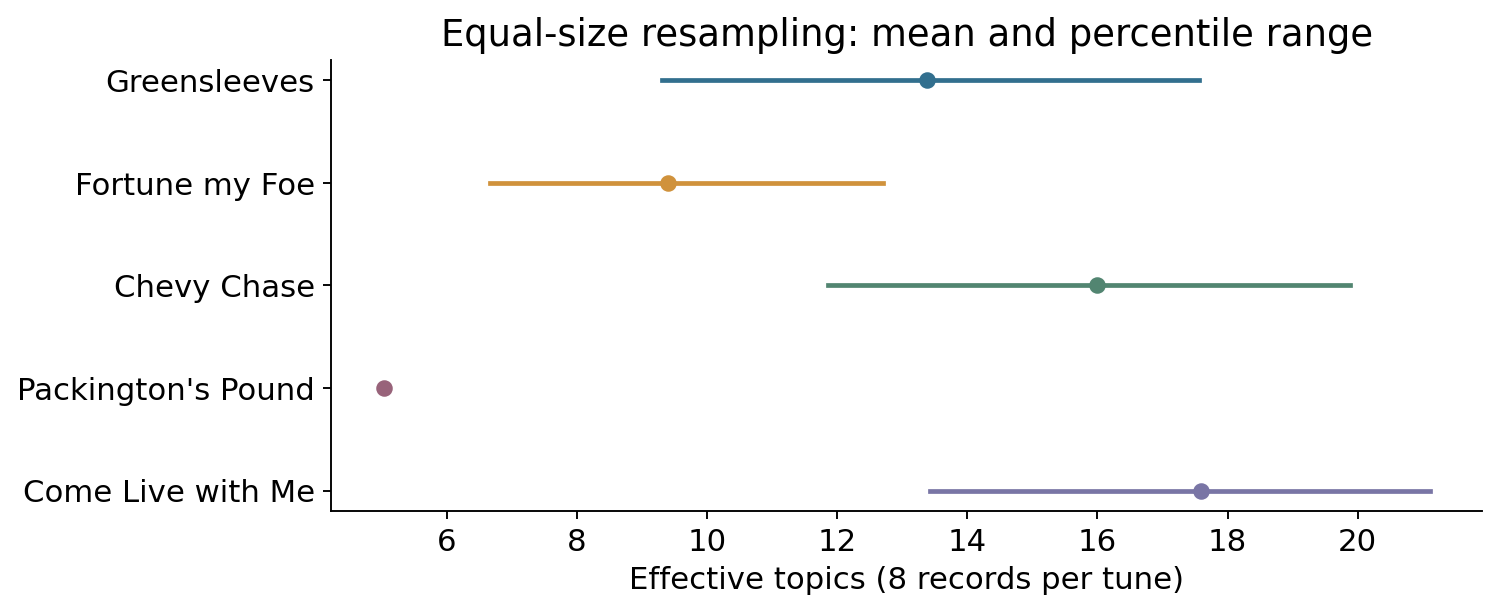

In [10]:
subsets=[[r for r in unique if t in r['tunes']] for t in tune_ids]
eligible_sizes=[len(s) for s in subsets if len(s)>=5]
m=min(eligible_sizes) if eligible_sizes else 0
rng=np.random.default_rng(config['seed'])
balanced=[]
for t,subset in zip(tune_ids,subsets):
    if len(subset)<5 or m==0:
        continue
    values=[]
    for _ in range(500):
        ids=rng.choice(len(subset),size=m,replace=False)
        w,_=topic_matrix([subset[i] for i in ids],[t],topic_ids)
        values.append(np.exp(entropy(w[0])))
    balanced.append({'tune_id':t,'sample_size':m,'mean_effective_topics':float(np.mean(values)),
                     'q025':float(np.quantile(values,.025)),'q975':float(np.quantile(values,.975))})
save_csv(ROOT/'results/equal_size_sensitivity.csv',balanced)

display(pd.DataFrame(balanced).assign(tune=lambda d: d.tune_id.map(SHORT_NAMES))[
    ['tune', 'sample_size', 'mean_effective_topics', 'q025', 'q975']].round(4))
fig, ax = plt.subplots(figsize=(9, 3.8))
for i, row in enumerate(balanced):
    ax.plot([row['q025'], row['q975']], [i, i], color=COLORS[i], linewidth=2)
    ax.scatter(row['mean_effective_topics'], i, color=COLORS[i], zorder=3)
ax.set_yticks(range(len(balanced)), [SHORT_NAMES[r['tune_id']] for r in balanced]); ax.invert_yaxis()
ax.set_xlabel('Effective topics (8 records per tune)'); ax.set_title('Equal-size resampling: mean and percentile range')
fig.tight_layout(); save('equal_size')

## Tune–topic network and topic composition
Network edge widths represent fractional record weights. The heatmap shows each topic's share within a tune. Both figures display the fourteen labels with the greatest total weight; all observed labels contribute to the diversity calculations.

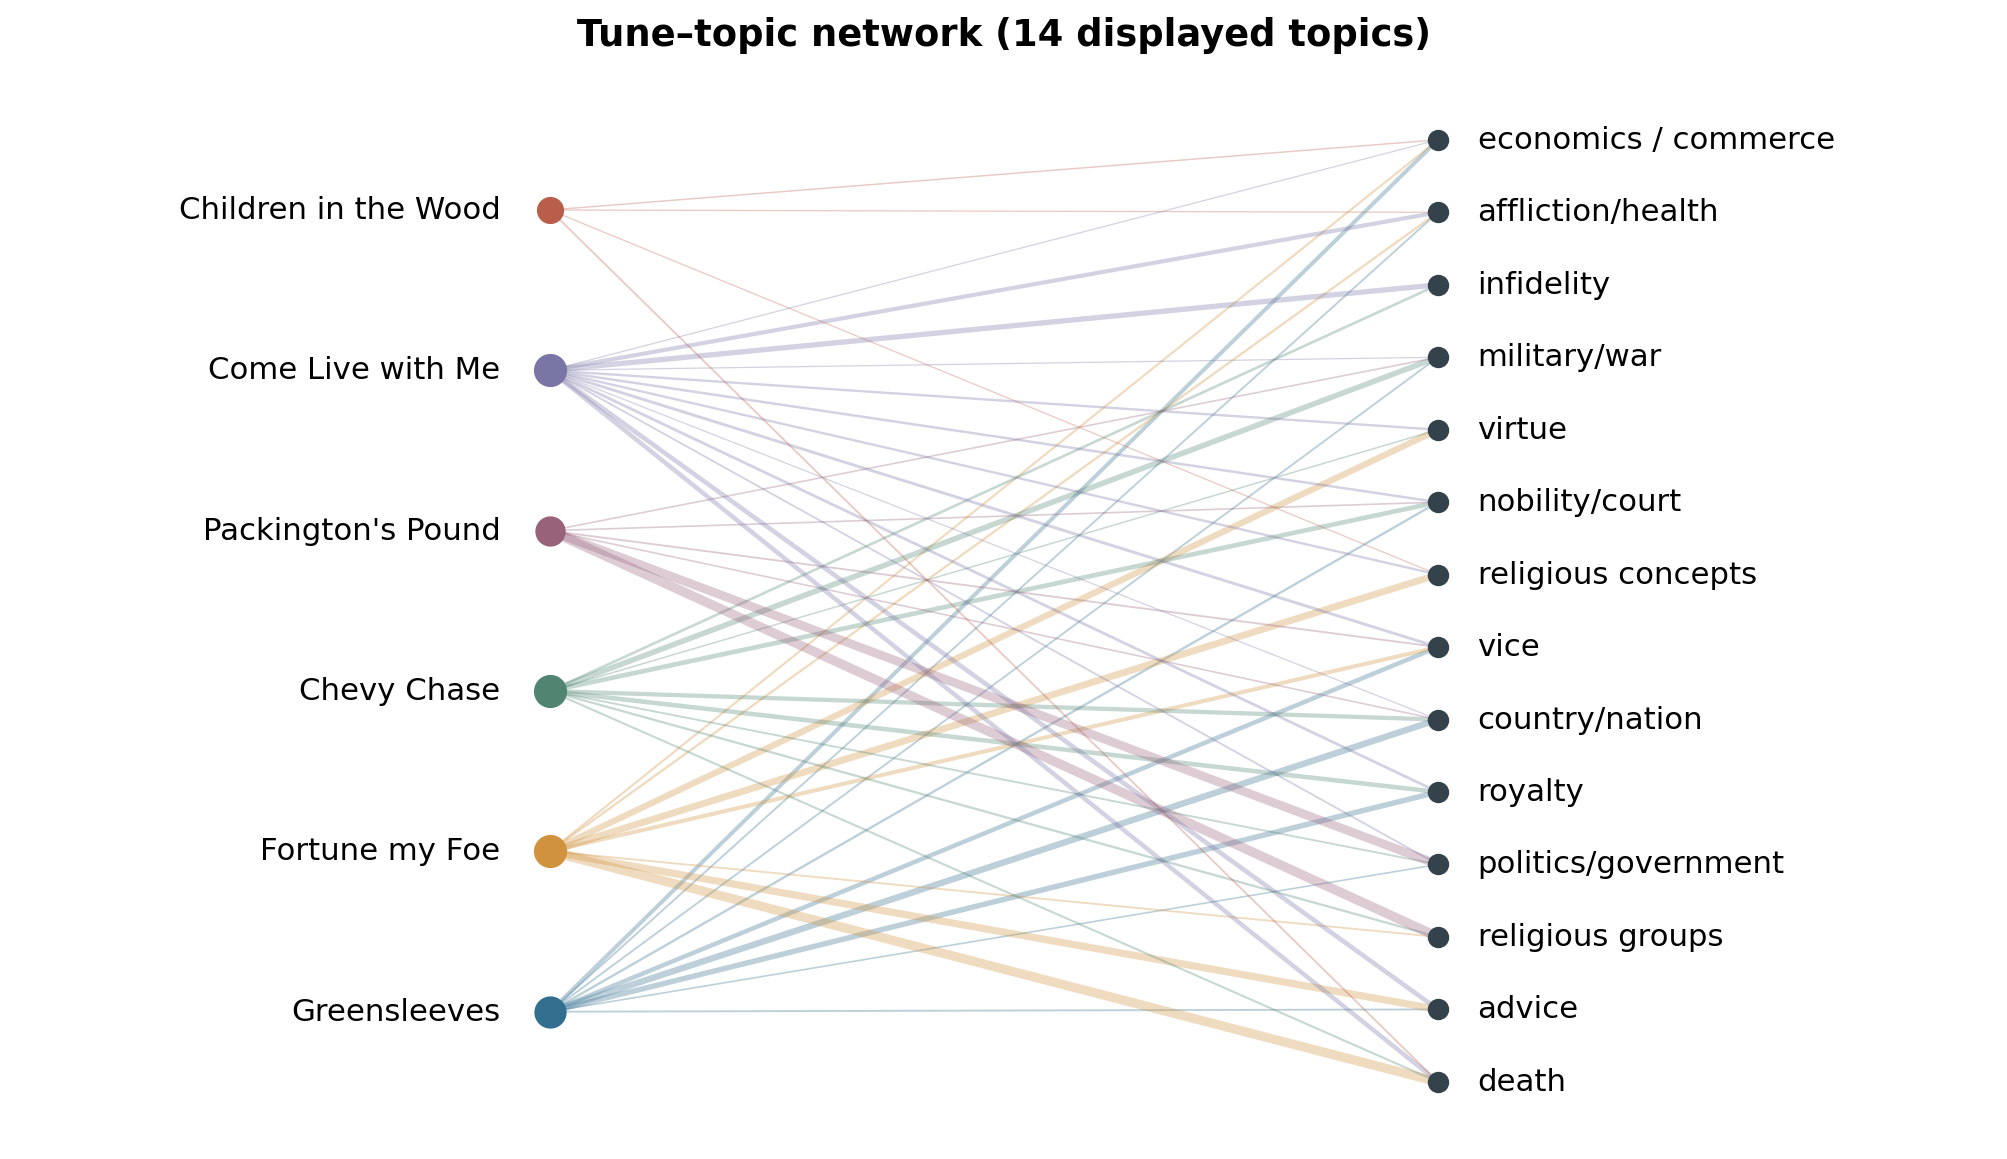

In [11]:
top=np.argsort(-weights.sum(axis=0))[:14]
# Bipartite graph: widths are fractional ballad counts, not causal flows.
fig,ax=plt.subplots(figsize=(12,7))
yleft=np.linspace(.1,.9,len(tune_ids));yright=np.linspace(.03,.97,len(top))
for i,t in enumerate(tune_ids):
    for j,k in enumerate(top):
        if weights[i,k]>0:
            ax.plot([.27,.72],[yleft[i],yright[j]],color=COLORS[i],alpha=.32,
                    lw=.4+weights[i,k]*1.2,zorder=1)
    ax.scatter(.27,yleft[i],s=100+rows[i]['n_records']*5,color=COLORS[i],zorder=3)
    ax.text(.245,yleft[i],SHORT_NAMES[t],ha='right',va='center',fontsize=13)
for j,k in enumerate(top):
    ax.scatter(.72,yright[j],s=65,color='#34434b',zorder=3)
    ax.text(.74,yright[j],labels[topic_ids[k]],ha='left',va='center',fontsize=13)
ax.set_xlim(0,1);ax.set_ylim(-.03,1.05);ax.axis('off')
ax.set_title('Tune–topic network (14 displayed topics)',fontweight='bold')
fig.tight_layout();save('network')

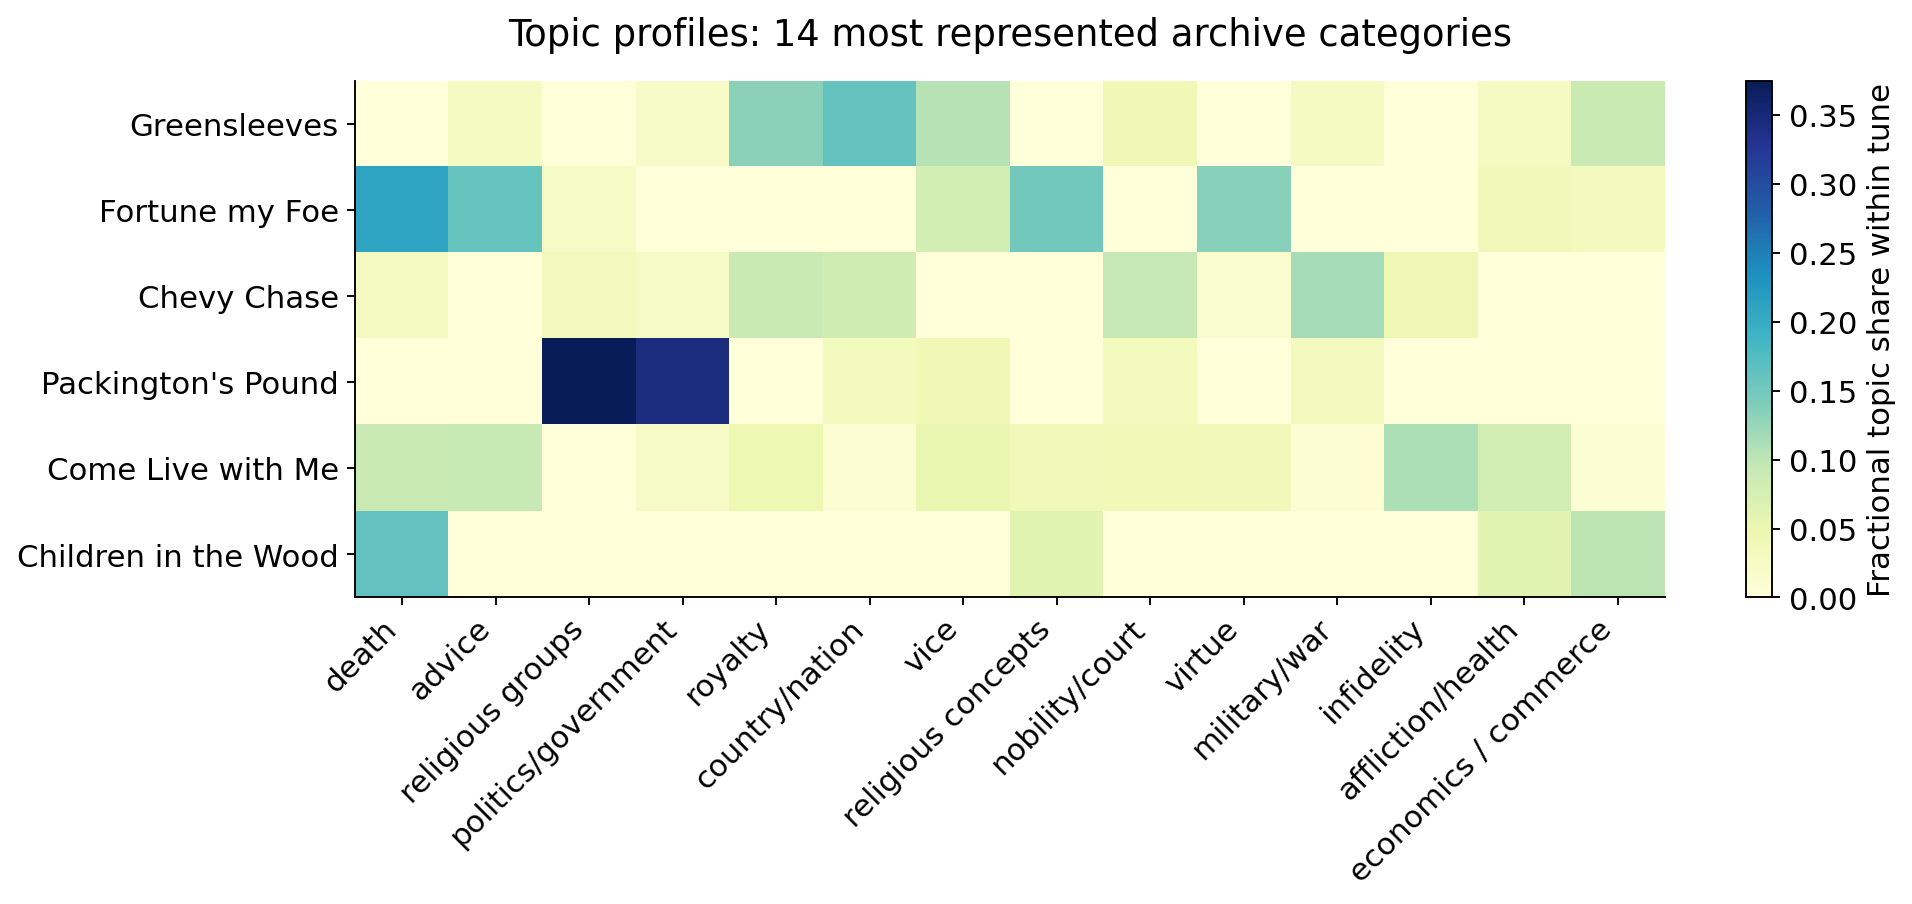

In [12]:
top=np.argsort(-weights.sum(axis=0))[:14]
proportions=np.divide(weights,weights.sum(axis=1,keepdims=True),out=np.zeros_like(weights),where=weights.sum(axis=1,keepdims=True)!=0)
fig,ax=plt.subplots(figsize=(12,5.5))
im=ax.imshow(proportions[:,top],cmap='YlGnBu',aspect='auto')
ax.set_yticks(range(len(names)),names)
ax.set_xticks(range(len(top)),[labels[topic_ids[k]] for k in top],rotation=45,ha='right')
fig.colorbar(im,ax=ax,label='Fractional topic share within tune')
ax.set_title('Topic profiles: 14 most represented archive categories',pad=15)
fig.tight_layout();save('topic_heatmap')

## Lexical representation, text similarity, and permutation comparison
TF–IDF uses individual words, English stop-word removal, a minimum document frequency of two, logarithmic term frequency, and L2 normalization. Cosine similarity measures proximity between lyric vectors.

The comparison statistic subtracts the mean similarity of other text pairs from the mean similarity of pairs sharing a selected tune. The reference distribution keeps the text vectors fixed and reassigns complete tune-membership sets at the document level 999 times, preserving group sizes. Every random procedure uses seed 42.

In [13]:
def text_matrix(records):
    vectorizer = TfidfVectorizer(stop_words='english', min_df=2, max_df=1.0,
                                ngram_range=(1,1), sublinear_tf=True,
                                token_pattern=r"(?u)\b[a-z][a-z']+\b")
    x = vectorizer.fit_transform([r['normalized_lyrics'] for r in records])
    if x.shape[1] < 2:
        raise ValueError('Insufficient vocabulary for text comparison')
    return x, vectorizer, cosine_similarity(x)

def pair_stat(sim, records):
    i,j = np.triu_indices(len(records), k=1)
    sets = [set(r['tunes']) for r in records]
    same = np.array([bool(sets[a] & sets[b]) for a,b in zip(i,j)])
    if not same.any() or same.all():
        raise ValueError('Need both shared-tune and disjoint-tune pairs')
    within,between = sim[i,j][same],sim[i,j][~same]
    return float(within.mean() - between.mean()), float(within.mean()), float(between.mean()), int(same.sum()), int((~same).sum())

def permutation_test(sim, records, config):
    observed,within,between,nw,nb = pair_stat(sim,records)
    rng = np.random.default_rng(config['seed'])
    null = []
    for _ in range(config['permutations']):
        ix = rng.permutation(len(records))
        shuffled = [{'tunes': records[j]['tunes']} for j in ix]
        null.append(pair_stat(sim,shuffled)[0])
    null = np.array(null)
    # Predeclared directional question: is within-tune similarity greater?
    p = float((1 + np.count_nonzero(null >= observed)) / (1 + len(null)))
    return {'difference': observed, 'within_mean': within, 'between_mean': between,
            'within_pairs': nw, 'between_pairs': nb, 'permutations':len(null),
            'p_one_sided': p, 'null_mean':float(null.mean()),
            'null_q025':float(np.quantile(null,.025)), 'null_q975':float(np.quantile(null,.975))}, null

In [14]:
x, vectorizer, sim = text_matrix(unique)
perm, null = permutation_test(sim, unique, config)
write_json(ROOT / 'results/permutation_test.json', perm)
save_csv(ROOT / 'results/permutation_null.csv', [{'difference': float(v)} for v in null])
terms = vectorizer.get_feature_names_out()
termrows = []
for t in tune_ids:
    ix = [i for i, r in enumerate(unique) if t in r['tunes']]
    average = np.asarray(x[ix].mean(axis=0)).ravel()
    termrows.append({'tune_id': t, 'tune': config['tunes'][t],
                     'top_terms': ', '.join(terms[np.argsort(-average)[:12]])})
save_csv(ROOT / 'results/top_terms.csv', termrows)
pairs = []
for i in range(len(unique)):
    for j in range(i + 1, len(unique)):
        pairs.append({'id_a': unique[i]['ebba_id'], 'id_b': unique[j]['ebba_id'],
                      'shared_tunes': '|'.join(sorted(set(unique[i]['tunes']) & set(unique[j]['tunes']))),
                      'cosine': float(sim[i,j]), 'url_a': unique[i]['source_url'], 'url_b': unique[j]['source_url']})
save_csv(ROOT / 'results/text_pairs.csv', sorted(pairs, key=lambda p: -p['cosine']))
display(pd.DataFrame([perm]).T.rename(columns={0: 'value'}))
display(pd.DataFrame(termrows)[['tune', 'top_terms']])

,value
difference,0.175266
within_mean,0.267427
between_mean,0.092162
within_pairs,368.000000
between_pairs,1648.000000
permutations,999.000000
p_one_sided,0.001000
null_mean,0.000679
null_q025,-0.014003
null_q975,0.019101


,tune,top_terms
0,Greensleeves,"fine, england, i'le, alwayes, did, sit, mault,..."
1,Fortune my Foe,"doth, death, time, pray, repent, live, love, s..."
2,Chevy Chase,"did, king, piercy, dowglas, sir, chase, thy, e..."
3,Packington's Pound,"plot, popish, devil, scribling, fools, plots, ..."
4,Come Live with Me and Be My Love,"love, wanton, wife, did, beauty, gentle, frien..."
5,"Children in the Wood, The; Now Ponder Well","wretch, dyd, pretty, deeds, babes, woman, mone..."


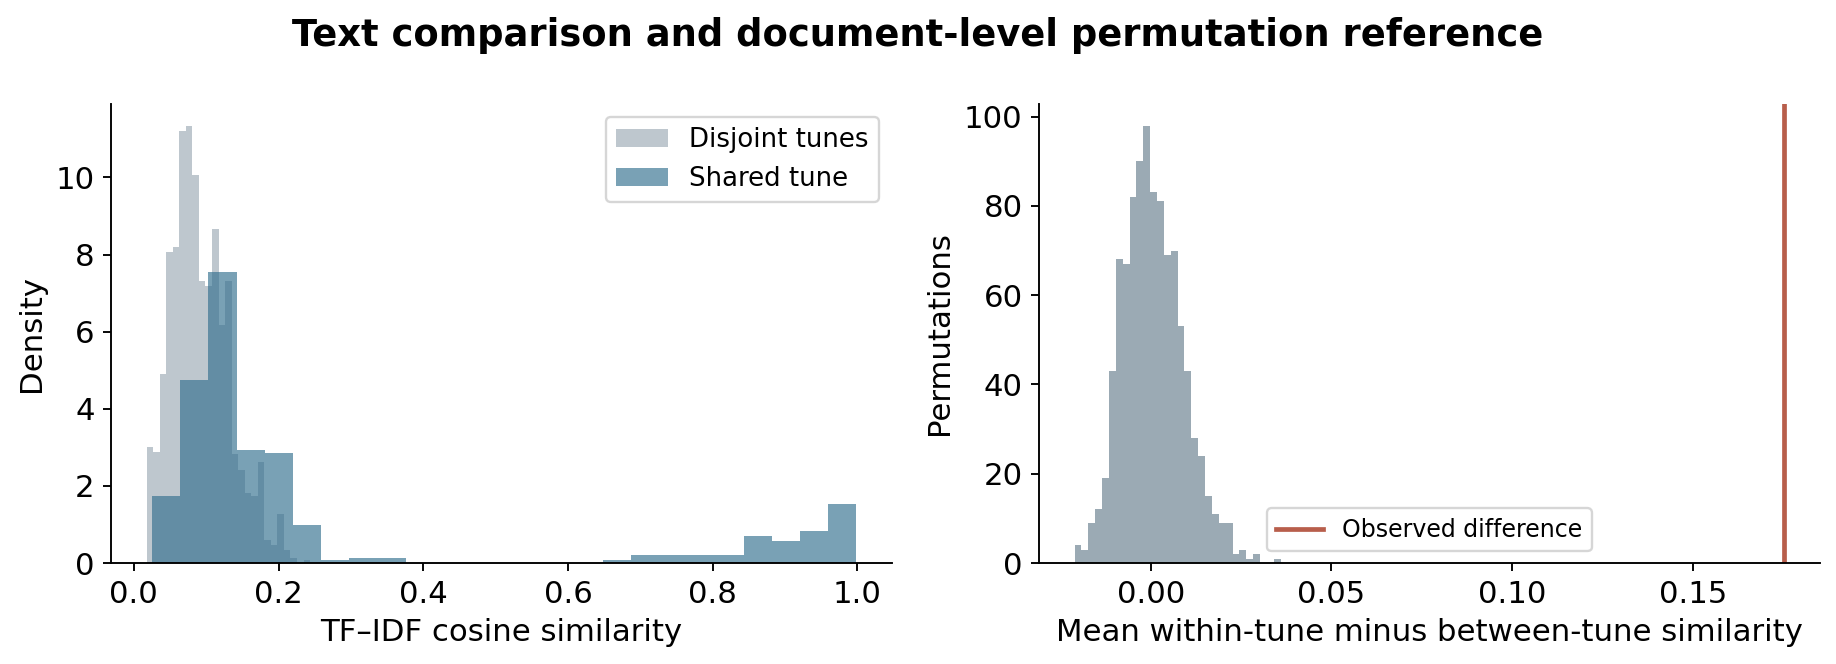

In [15]:
fig,axs=plt.subplots(1,2,figsize=(11,4))
i,j=np.triu_indices(len(unique),1)
same=np.array([bool(set(unique[a]['tunes'])&set(unique[b]['tunes'])) for a,b in zip(i,j)])
axs[0].hist(sim[i,j][~same],bins=25,alpha=.65,density=True,label='Disjoint tunes',color='#9baab4')
axs[0].hist(sim[i,j][same],bins=25,alpha=.65,density=True,label='Shared tune',color=COLORS[0])
axs[0].set_xlabel('TF–IDF cosine similarity');axs[0].set_ylabel('Density');axs[0].legend(fontsize=11)
axs[1].hist(null,bins=30,color='#9baab4')
axs[1].axvline(perm['difference'],color='#b85e4b',lw=2,label='Observed difference')
axs[1].set_xlabel('Mean within-tune minus between-tune similarity')
axs[1].set_ylabel('Permutations');axs[1].legend(fontsize=10)
fig.suptitle('Text comparison and document-level permutation reference',fontweight='bold')
fig.tight_layout();save('text_similarity')

## Sensitivity to closely related versions
The analysis connects lyrics whose cosine similarity reaches 0.90 or 0.95. Each connected component retains its lowest-ID record and that record's metadata. The comparison then reuses the original text vectors to recalculate the similarity difference. This procedure diagnoses the influence of closely related texts; the components have not undergone historical edition verification. The sensitivity analysis does not repeat the permutation test.

In [16]:
def near_duplicate_representatives(records, sim, threshold):
    """Connected components above a threshold; exploratory edition sensitivity."""
    parent = list(range(len(records)))
    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i
    for i in range(len(records)):
        for j in range(i+1,len(records)):
            if sim[i,j] >= threshold:
                a,b = find(i),find(j)
                parent[max(a,b)] = min(a,b)
    keep = [i for i in range(len(records)) if find(i)==i]
    return keep

,treatment,records,difference
0,Exact duplicates only,64,0.1753
1,Cosine threshold 0.95,47,0.1205
2,Cosine threshold 0.90,42,0.0876


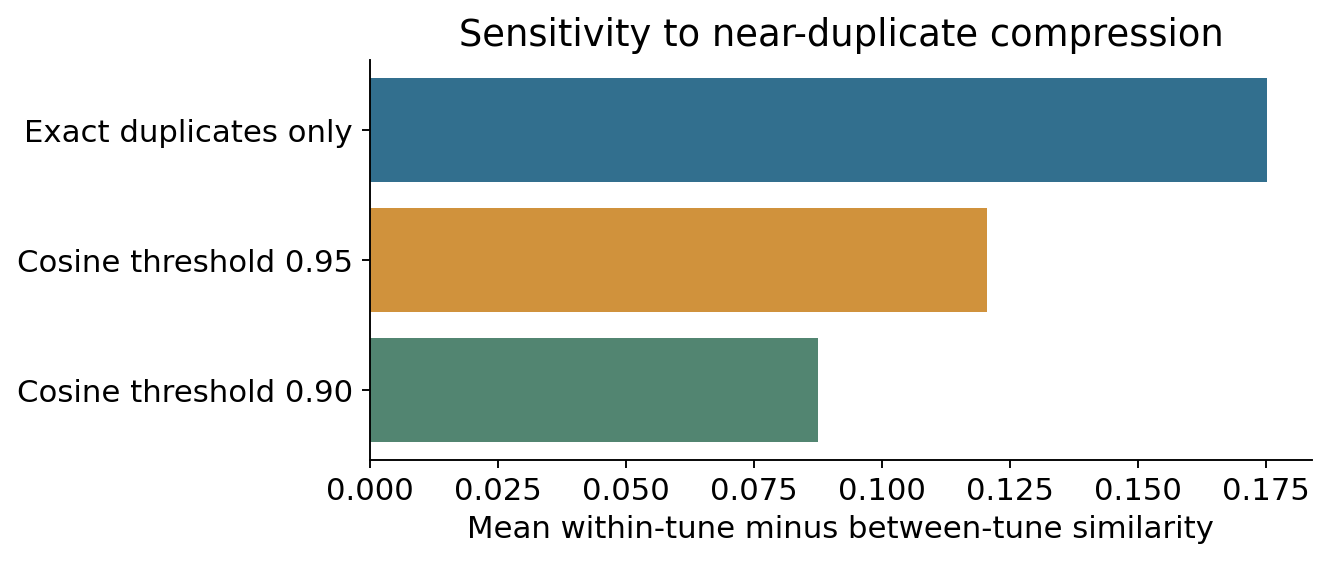

In [17]:
sensitivity=[]
for threshold in [.90,.95]:
    keep=near_duplicate_representatives(unique,sim,threshold)
    sub=[unique[i] for i in keep]
    d,w,b,nw,nb=pair_stat(sim[np.ix_(keep,keep)],sub)
    rr,_=describe_tunes(sub,tune_ids,topic_ids,{**config,'bootstrap_repeats':100})
    for r in rr:
        sensitivity.append({**r,'threshold':threshold,'total_records':len(sub),'similarity_difference':d})
save_csv(ROOT/'results/near_duplicate_sensitivity.csv',sensitivity)

comparison = [{'treatment': 'Exact duplicates only', 'records': len(unique), 'difference': perm['difference']}]
for threshold in [.95, .90]:
    row = next(r for r in sensitivity if r['threshold'] == threshold)
    comparison.append({'treatment': f'Cosine threshold {threshold:.2f}',
                       'records': row['total_records'], 'difference': row['similarity_difference']})
display(pd.DataFrame(comparison).round(4))
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh([r['treatment'] for r in comparison], [r['difference'] for r in comparison], color=COLORS[:3])
ax.invert_yaxis(); ax.set_xlabel('Mean within-tune minus between-tune similarity')
ax.set_title('Sensitivity to near-duplicate compression'); fig.tight_layout(); save('duplicate_sensitivity')

## Findings and consistency checks
The following checks verify relationships among the similarity matrix, text pairs, and topic weights. The report directly references the seven PDF figures generated by the current analysis in `results/figures/`.

In [18]:
validation={'manifest_records':len(manifest['memberships']),'unavailable_sources':len(config.get('unavailable_ids',[])),'xml_parsed':len(records)+len(excluded),
            'eligible_records':len(records),'excluded_records':len(excluded),'exact_unique_records':len(unique),
            'collapsed_records':len(records)-len(unique), 'topic_count':int((weights.sum(axis=0)>0).sum()),
            'tune_count':len(tune_ids),'network_edges':len(edges),'vocabulary_size':len(terms),
            'unmatched_keyword_records':sum(bool(r['unmatched_keywords']) for r in records+excluded),
            'missing_date_records':sum(not r['date_text'] for r in records+excluded),
            'missing_source_reference_records':sum(not r['source_reference'] for r in records+excluded),
            'token_min':min(r['tokens'] for r in unique),'token_median':float(np.median([r['tokens'] for r in unique])),
            'token_max':max(r['tokens'] for r in unique),
            'edge_weight_sum':float(weights.sum()),'tune_membership_sum':int(sum(r['n_records'] for r in rows))}
assert np.allclose(weights.sum(axis=1),[r['n_records'] for r in rows])

assert sim.shape == (len(unique), len(unique))
assert np.allclose(sim, sim.T) and np.allclose(np.diag(sim), 1)
assert perm['within_pairs'] + perm['between_pairs'] == len(unique) * (len(unique) - 1) // 2
assert len(null) == config['permutations']
assert validation['edge_weight_sum'] == validation['tune_membership_sum']
versions = {'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__,
            'scikit-learn': sklearn.__version__, 'matplotlib': matplotlib.__version__}
write_json(ROOT / 'results/summary.json', {'validation': validation, 'permutation': perm, 'versions': versions})
display(pd.Series(validation, name='value').to_frame())
display(Markdown(f"The main analysis retains **{len(unique)}** lyrics. The mean similarity difference between shared-tune and other pairs is **{perm['difference']:.4f}**, "
                 f"with a permutation reference p-value of **{perm['p_one_sided']:.3f}**. Compression at the 0.90 threshold gives a difference of **{comparison[2]['difference']:.4f}**. "
                 "Topic breadth and clusters of closely related texts both contribute to the observed pattern of tune reuse."))

,value
manifest_records,101.0
unavailable_sources,4.0
xml_parsed,97.0
eligible_records,65.0
excluded_records,32.0
exact_unique_records,64.0
collapsed_records,1.0
topic_count,43.0
tune_count,6.0
network_edges,106.0


The main analysis retains **64** lyrics. The mean similarity difference between shared-tune and other pairs is **0.1753**, with a permutation reference p-value of **0.001**. Compression at the 0.90 threshold gives a difference of **0.0876**. Topic breadth and clusters of closely related texts both contribute to the observed pattern of tune reuse.

## Sources
English Broadside Ballad Archive, University of California, Santa Barbara:
[Archive](https://ebba.english.ucsb.edu/), [TEI XML](https://ebba.english.ucsb.edu/page/tei-xml),
[Keywords](https://ebba.english.ucsb.edu/page/keywords), and [Use Policy](https://ebba.english.ucsb.edu/page/use-policy).
The lexical model follows the [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) documentation.
Source attribution and licensing details appear in `DATA_LICENSE.md`.